In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.core.pylabtools import figsize

# The URL points directly to the raw CSV file on GitHub for Confirmed Global Cases
URL = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'
df_raw = pd.read_csv(URL)

# Inspect the first few rows to confirm the data loaded correctly
print("Raw Data Head:")
print(df_raw.head(5))

Raw Data Head:
  Province/State Country/Region       Lat       Long  1/22/20  1/23/20  \
0            NaN    Afghanistan  33.93911  67.709953        0        0   
1            NaN        Albania  41.15330  20.168300        0        0   
2            NaN        Algeria  28.03390   1.659600        0        0   
3            NaN        Andorra  42.50630   1.521800        0        0   
4            NaN         Angola -11.20270  17.873900        0        0   

   1/24/20  1/25/20  1/26/20  1/27/20  ...  2/28/23  3/1/23  3/2/23  3/3/23  \
0        0        0        0        0  ...   209322  209340  209358  209362   
1        0        0        0        0  ...   334391  334408  334408  334427   
2        0        0        0        0  ...   271441  271448  271463  271469   
3        0        0        0        0  ...    47866   47875   47875   47875   
4        0        0        0        0  ...   105255  105277  105277  105277   

   3/4/23  3/5/23  3/6/23  3/7/23  3/8/23  3/9/23  
0  209369  20

In [60]:
# The URL for the global deaths time series
DEATHS_URL = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv'
df_deaths_raw = pd.read_csv(DEATHS_URL)

print("Raw Deaths Data Head:")
print(df_deaths_raw.head(3))

Raw Deaths Data Head:
  Province/State Country/Region       Lat       Long  1/22/20  1/23/20  \
0            NaN    Afghanistan  33.93911  67.709953        0        0   
1            NaN        Albania  41.15330  20.168300        0        0   
2            NaN        Algeria  28.03390   1.659600        0        0   

   1/24/20  1/25/20  1/26/20  1/27/20  ...  2/28/23  3/1/23  3/2/23  3/3/23  \
0        0        0        0        0  ...     7896    7896    7896    7896   
1        0        0        0        0  ...     3598    3598    3598    3598   
2        0        0        0        0  ...     6881    6881    6881    6881   

   3/4/23  3/5/23  3/6/23  3/7/23  3/8/23  3/9/23  
0    7896    7896    7896    7896    7896    7896  
1    3598    3598    3598    3598    3598    3598  
2    6881    6881    6881    6881    6881    6881  

[3 rows x 1147 columns]


In [61]:
# --- CLEANING DEATHS ---
# 1. Sum by country and drop location columns
df_deaths_agg = df_deaths_raw.drop(columns=['Lat', 'Long', 'Province/State']).groupby('Country/Region').sum()
# 2. Transpose (flip) and convert index to dates
df_deaths_ts = df_deaths_agg.T
df_deaths_ts.index = pd.to_datetime(df_deaths_ts.index)

# --- CLEANING CASES ---
df_cases_agg = df_raw.drop(columns=['Lat', 'Long', 'Province/State']).groupby('Country/Region').sum()
# 4. Transpose and convert index to dates
df_cases_ts = df_cases_agg.T
df_cases_ts.index = pd.to_datetime(df_cases_ts.index)

print("Data cleaning complete. Tables created for both Deaths and Cases.")

Data cleaning complete. Tables created for both Deaths and Cases.


C:\Users\zsche\AppData\Local\Temp\ipykernel_16156\2401683264.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_deaths_ts.index = pd.to_datetime(df_deaths_ts.index)
C:\Users\zsche\AppData\Local\Temp\ipykernel_16156\2401683264.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cases_ts.index = pd.to_datetime(df_cases_ts.index)


In [62]:
# 1. Get the most recent date's totals for all countries
# We look at the last row (iloc[-1]) of our time series data
latest_totals = df_deaths_ts.iloc[-1].sort_values(ascending=False)

#2. Now find the top 10 countries with most deaths
# .head(10) picks the top ones, .index grabs the names, .tolist() makes it a list
top_10_countries = latest_totals.head(10).index.tolist()

# 3. Isolate the US data into its own DataFrame for plotting later
# Note: In this dataset, the USA is labeled as 'US'
usa_cases = df_cases_ts['US']
usa_deaths = df_deaths_ts['US']
# 3. Calculate Case Fatality Rate (CFR) - Ratio of Deaths to Case
usa_case_to_death_ratio = (usa_deaths/usa_cases) * 100

print(f"Top 10 countries with most cases are:\n {top_10_countries}")
print("-"*290)
print(f"USA Total Cases: {usa_cases.iloc[-1]:,.0f}")
print(f"USA Total Deaths: {usa_deaths.iloc[-1]:,.0f}")
print(f"USA Case Fatality Rate: {usa_case_to_death_ratio.iloc[-1]:.2f}%")



Top 10 countries with most cases are:
 ['US', 'Brazil', 'India', 'Russia', 'Mexico', 'United Kingdom', 'Peru', 'Italy', 'Germany', 'France']
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
USA Total Cases: 103,802,702
USA Total Deaths: 1,123,836
USA Case Fatality Rate: 1.08%


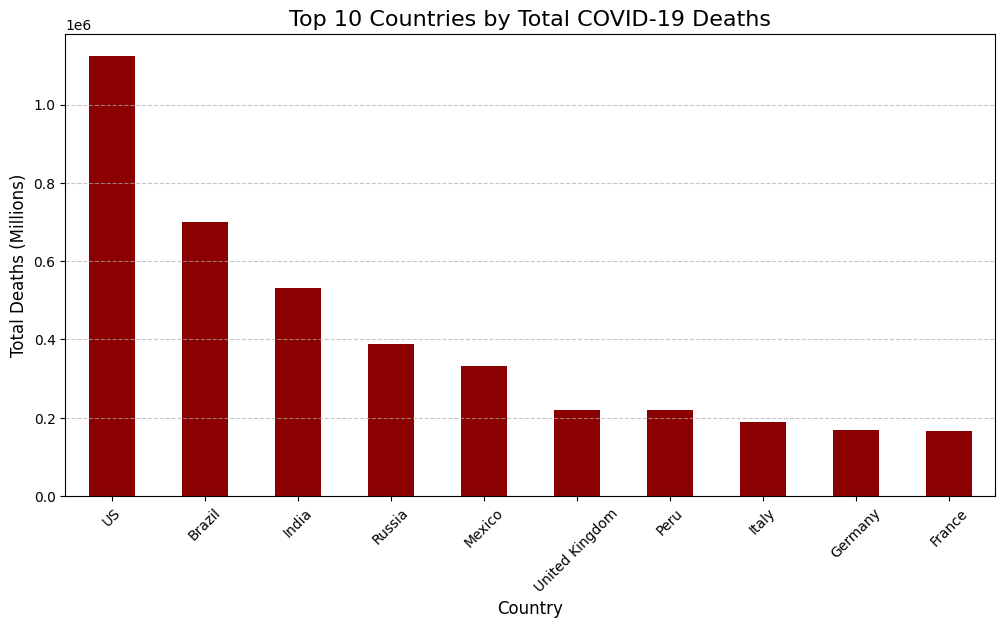

In [63]:
import matplotlib.pyplot as plt

# 1. Get the death totals for just our Top 10 countries
top_ten_deaths = latest_totals.head(10)

plt.figure(figsize=(12, 6))
top_ten_deaths.plot(kind='bar', color='darkred')

# 3. Add professional styling
plt.title('Top 10 Countries by Total COVID-19 Deaths', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Deaths (Millions)', fontsize=12)
plt.xticks(rotation=45) # Rotates country names so they don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Show the chart
plt.show()


98.9173345410604 %


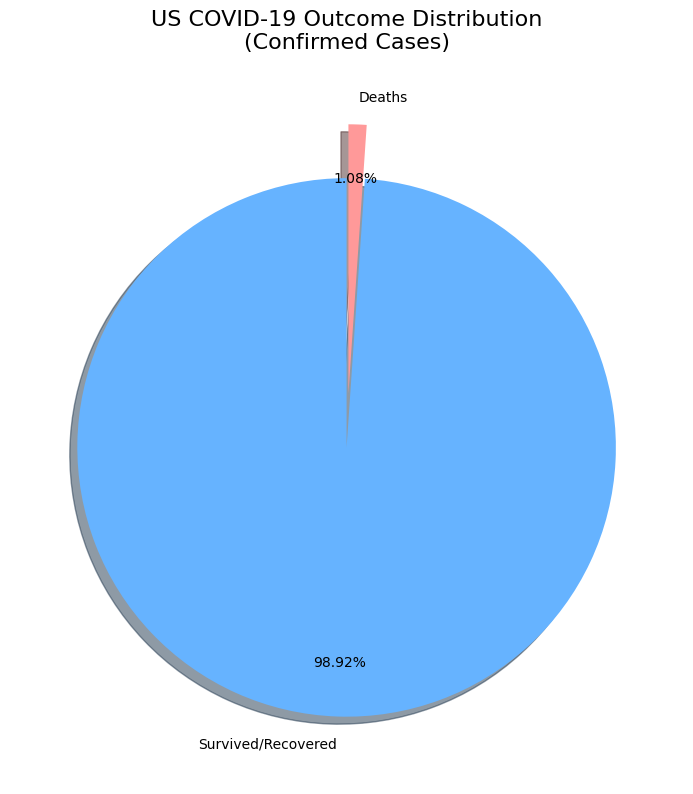

In [64]:
import matplotlib.pyplot as plt

final_death_rate = usa_case_to_death_ratio.iloc[-1]
final_survival_rate = 100 - final_death_rate
print(final_survival_rate,"%")

# 2. Prepare data for a Pie Chart
labels = ['Survived/Recovered', 'Deaths']
sizes = [final_survival_rate, final_death_rate]
colors = ['#66b3ff', '#ff9999'] # Blue for survival, Red for deaths
explode = (0, 0.2)  # "Explode" the death slice to make it stand out

plt.figure(figsize=(8,8))
plt.title('US COVID-19 Outcome Distribution\n(Confirmed Cases)', fontsize=16, y=1.08)

plt.pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%',
        startangle=90, colors=colors, shadow=True,
        labeldistance=1.1, pctdistance=0.8)
plt.tight_layout()
plt.show()

In [65]:
# Calculate the difference between each day for cases
usa_daily_cases = usa_cases.diff()

# Calculate the difference between each day for deaths
usa_daily_deaths = usa_deaths.diff()

usa_daily_cases_smoothed = usa_daily_cases.rolling(window=7).mean()
usa_daily_death_smoothed = usa_daily_deaths.rolling(window=7).mean()

# Quick check: print the last 5 days of new cases to see the daily numbers
print("Recent Daily New Cases:")
print(usa_daily_cases.tail())
print("-" * 30)
print("Recent Daily New Deaths:")
print(usa_daily_deaths.tail())

Recent Daily New Cases:
2023-03-05    -3862.0
2023-03-06     8564.0
2023-03-07    35371.0
2023-03-08    64861.0
2023-03-09    46931.0
Name: US, dtype: float64
------------------------------
Recent Daily New Deaths:
2023-03-05    -38.0
2023-03-06     47.0
2023-03-07    335.0
2023-03-08    730.0
2023-03-09    590.0
Name: US, dtype: float64


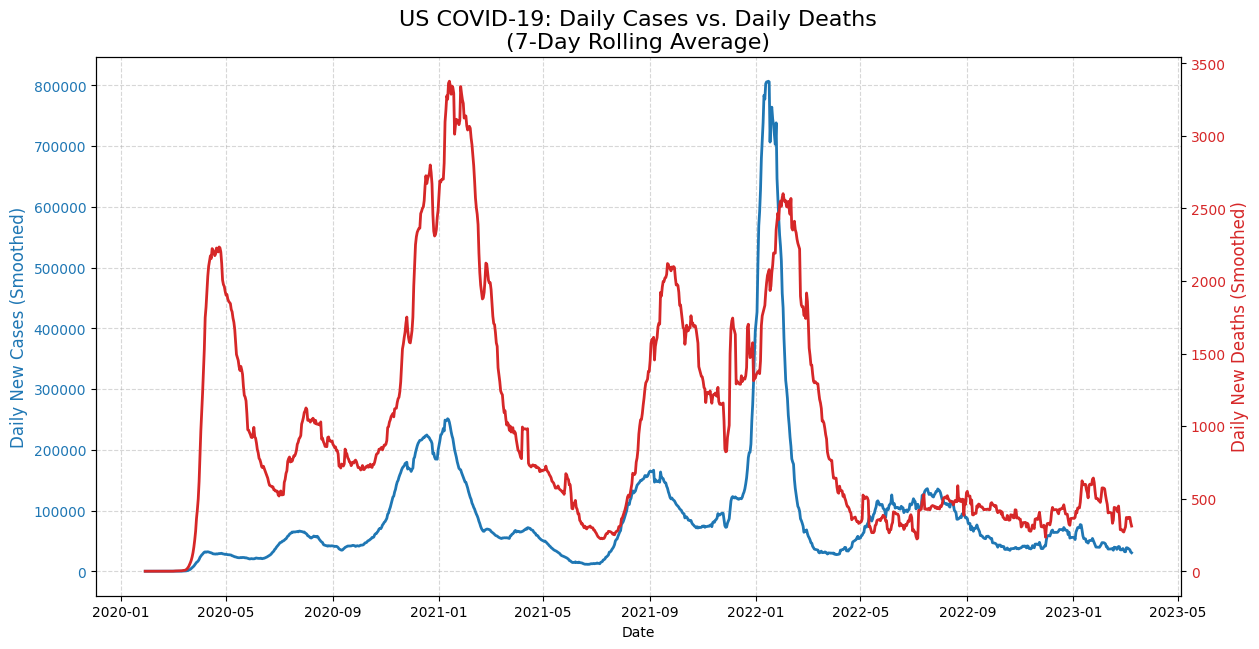

In [66]:
import matplotlib.pyplot as plt

# 1. Create the figure and the first axis (ax1)
fig, ax1 = plt.subplots(figsize=(14, 7))

# 2. Plot Smoothed Daily Cases on the left axis
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily New Cases (Smoothed)', color='tab:blue', fontsize=12)
ax1.plot(usa_daily_cases_smoothed, color='tab:blue', linewidth=2, label='Daily Cases')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# 3. Create a second axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()

# 4. Plot Smoothed Daily Deaths on the right axis
ax2.set_ylabel('Daily New Deaths (Smoothed)', color='tab:red', fontsize=12)
ax2.plot(usa_daily_death_smoothed, color='tab:red', linewidth=2, label='Daily Deaths')
ax2.tick_params(axis='y', labelcolor='tab:red')

# 5. Professional Styling
plt.title('US COVID-19: Daily Cases vs. Daily Deaths\n(7-Day Rolling Average)', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.5)

# 6. Show the plot
plt.show()

In [67]:
import pandas as pd

'''
This is a great analytical move. Comparing the US to Sweden is particularly interesting for your argument. Sweden was famous for having fewer lockdowns and a different social approach, so comparing their "Survival Rate" to the US helps determine if the risk was truly universal or based on policy.
'''

sweden_data = df_raw.loc[df_raw['Country/Region'] == 'Sweden']

# 1. Sum up all rows for Sweden (to get the national total)
# We start from column 4 because that's where the date columns begin
sweden_cases = sweden_data.iloc[:, 4:].sum()

# 2. Do the same for the Deaths dataframe
# (Make sure deaths_df or df_deaths_raw is defined in a previous cell)
sweden_deaths_data = df_deaths_raw.loc[df_deaths_raw['Country/Region'] == 'Sweden']
sweden_deaths = sweden_deaths_data.iloc[:, 4:].sum()

# 3. Calculate the Sweden Case Fatality Rate (CFR)
sweden_death_rate = (sweden_deaths / sweden_cases) * 100

# 4. Find the final Survival Rate
# .iloc[-1] gets the very last date in the dataset
final_swe_death_val = sweden_death_rate.iloc[-1]
final_swe_survival_rate = 100 - final_swe_death_val

# 5. Output the results
print(f"Sweden Total Confirmed Cases: {sweden_cases.iloc[-1]:,.0f}")
print(f"Sweden Total Deaths:          {sweden_deaths.iloc[-1]:,.0f}")
print("-" * 35)
print(f"Sweden Survival Rate:         {final_swe_survival_rate:.2f}%")

Sweden Total Confirmed Cases: 2,699,339
Sweden Total Deaths:          23,777
-----------------------------------
Sweden Survival Rate:         99.12%


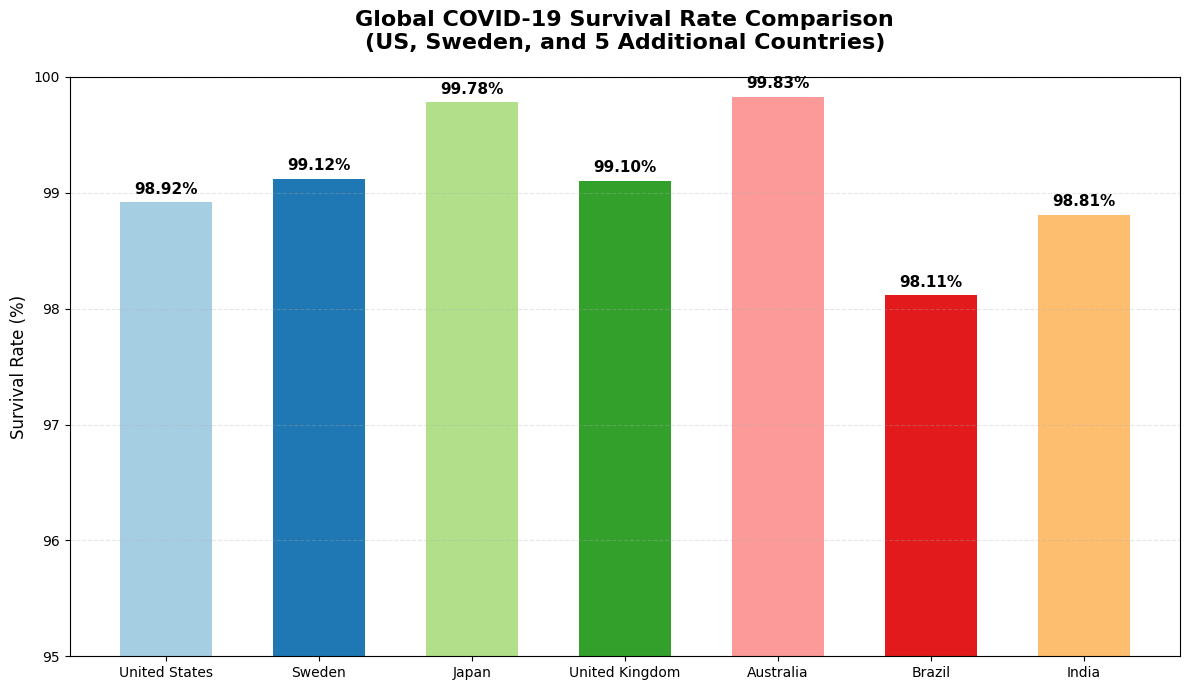

In [68]:
import matplotlib.pyplot as plt

# 1. Set up the lists with your existing US and Sweden data
labels = ['United States', 'Sweden']
survival_values = [final_survival_rate, final_swe_survival_rate]

# 2. Add 5 more countries to the list
extra_countries = ['Japan', 'United Kingdom', 'Australia', 'Brazil', 'India']

# 3. Loop through and calculate survival rates for the new countries
for country in extra_countries:
    # Get cases and deaths using the same logic we used for Sweden
    c_data = df_raw.loc[df_raw['Country/Region'] == country].iloc[:, 4:].sum()
    d_data = df_deaths_raw.loc[df_deaths_raw['Country/Region'] == country].iloc[:, 4:].sum()

    # Calculate final survival rate: 100 - ((Deaths / Cases) * 100)
    if c_data.iloc[-1] > 0:
        s_rate = 100 - ((d_data.iloc[-1] / c_data.iloc[-1]) * 100)
        labels.append(country)
        survival_values.append(s_rate)

# 4. Create the figure
plt.figure(figsize=(12, 7))
colors = plt.cm.Paired(range(len(labels))) # Gives each bar a distinct color
bars = plt.bar(labels, survival_values, color=colors, width=0.6)

# 5. THE TRICK: Zoom in on the 95% - 100% range
plt.ylim(95, 100)

# 6. Add details and styling
plt.title('Global COVID-19 Survival Rate Comparison\n(US, Sweden, and 5 Additional Countries)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Survival Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 7. Add the exact percentage labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\zsche\AppData\Local\Temp\ipykernel_16156\848703904.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swe_normalized.index = pd.to_datetime(swe_normalized.index)


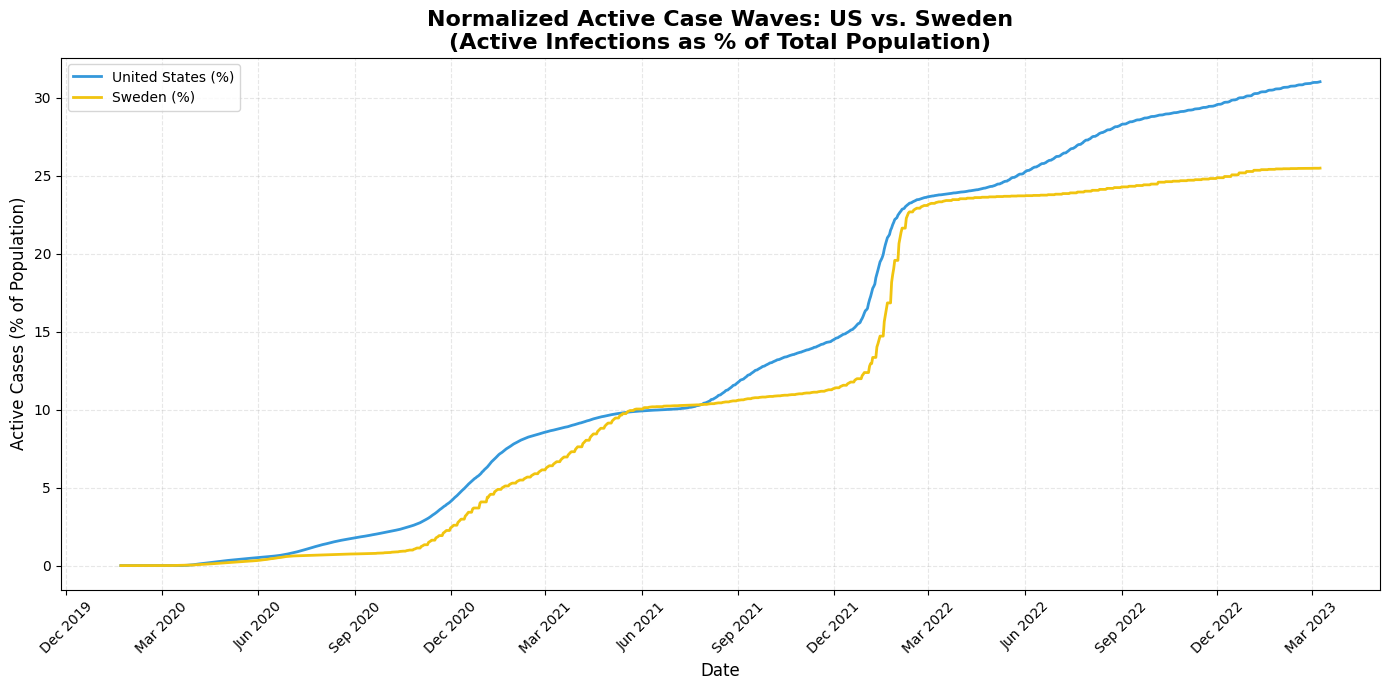

In [69]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Normalization (Data Prep)
usa_population = 331000000
usa_active = usa_cases - usa_deaths
usa_normalized = (usa_active / usa_population) * 100

swe_population = 10500000
swe_active = sweden_cases - sweden_deaths
swe_normalized = (swe_active / swe_population) * 100

# Convert indexes to datetime so Matplotlib understands the timeline
usa_normalized.index = pd.to_datetime(usa_normalized.index)
swe_normalized.index = pd.to_datetime(swe_normalized.index)
# ----------------

# 2. Create the graph
plt.figure(figsize=(14, 7))

plt.plot(usa_normalized.index, usa_normalized, label='United States (%)', color='#3498db', linewidth=2)
plt.plot(swe_normalized.index, swe_normalized, label='Sweden (%)', color='#f1c40f', linewidth=2)

# 3. Polish and Labels
plt.title('Normalized Active Case Waves: US vs. Sweden\n(Active Infections as % of Total Population)', fontsize=16, fontweight='bold')
plt.ylabel('Active Cases (% of Population)', fontsize=12)
plt.xlabel('Date', fontsize=12)

# Formatting the dates on the X-axis so they are readable
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

--- DAILY NEW CASE PEAKS (THE TRUE WAVES) ---
US Daily Peak:     0.4092% on 2022-01-10
Sweden Daily Peak: 1.3237% on 2022-01-25
US Smoothed Peak:     0.2438%
Sweden Smoothed Peak: 0.3897%


C:\Users\zsche\AppData\Local\Temp\ipykernel_16156\3877937408.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  swe_daily_pct.index = pd.to_datetime(swe_daily_pct.index)


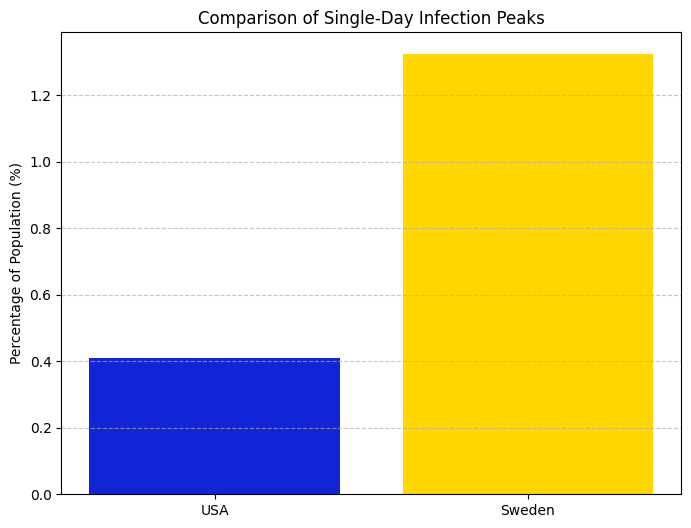

In [84]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Get the difference between today and yesterday
usa_daily_new = usa_cases.diff()
swe_daily_new = sweden_cases.diff()

# 2. Normalize it (New cases as a % of population)
usa_daily_pct = (usa_daily_new / usa_population) * 100
swe_daily_pct = (swe_daily_new / swe_population) * 100

usa_daily_max = usa_daily_pct.max()
usa_daily_date = usa_daily_pct.idxmax()

# Force Sweden's index to be "Smart Dates"
swe_daily_pct.index = pd.to_datetime(swe_daily_pct.index)

# Now find the peak date again
swe_daily_date = swe_daily_pct.idxmax()

swe_daily_max = swe_daily_pct.max()
swe_daily_date = swe_daily_pct.idxmax()

# Print the "Clean" results
print("--- DAILY NEW CASE PEAKS (THE TRUE WAVES) ---")
print(f"US Daily Peak:     {usa_daily_max:.4f}% on {usa_daily_date.strftime('%Y-%m-%d')}")
print(f"Sweden Daily Peak: {swe_daily_max:.4f}% on {swe_daily_date.strftime('%Y-%m-%d')}")

countries_U_and_S = ['USA', 'Sweden']
Us_and_swe_val = [usa_daily_max, swe_daily_max]

plt.figure(figsize=(8,6))
plt.bar(countries_U_and_S, Us_and_swe_val, color=['#1125D6', 'gold'])

# 1. Create the smooth variables (The "True Wave")
# window=7 means it takes the average of the last 7 days
usa_smooth = usa_daily_pct.rolling(window=7).mean()
swe_smooth = swe_daily_pct.rolling(window=7).mean()

# Find the peak of the 7-day average instead of the raw daily data
usa_smooth_peak = usa_smooth.max()
swe_smooth_peak = swe_smooth.max()

print(f"US Smoothed Peak:     {usa_smooth_peak:.4f}%")
print(f"Sweden Smoothed Peak: {swe_smooth_peak:.4f}%")

#Pro labels
plt.title("Comparison of Single-Day Infection Peaks")
plt.ylabel("Percentage of Population (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7) # Makes it easier to read the height
plt.show()

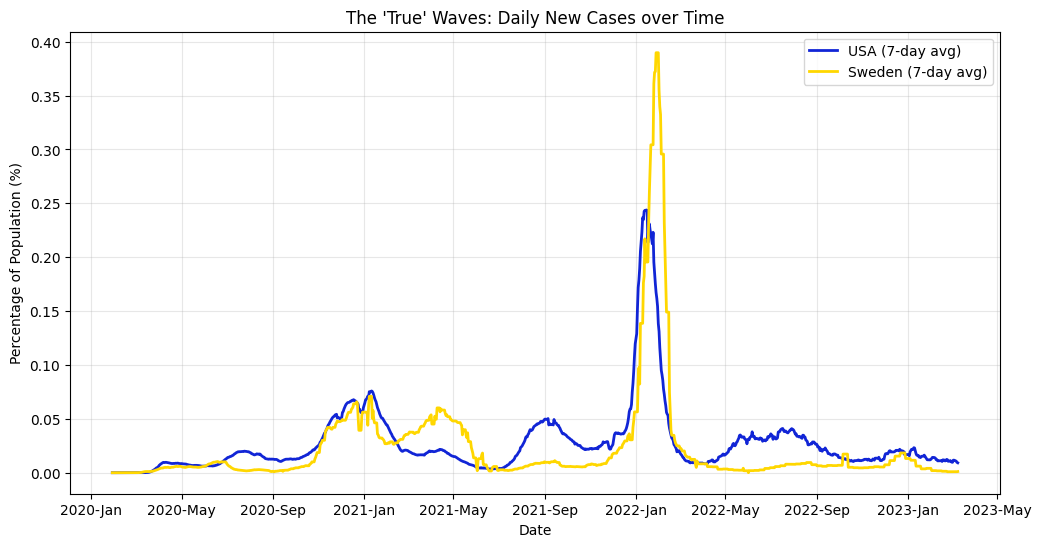

In [86]:

plt.figure(figsize=(12, 6))
#Plot the smooth lines
plt.plot(usa_smooth.index, usa_smooth, label='USA (7-day avg)', color='#1125D6', linewidth=2)
plt.plot(swe_smooth.index, swe_smooth, label='Sweden (7-day avg)', color='gold', linewidth=2)

# Professional Labels and Formatting
plt.title("The 'True' Waves: Daily New Cases over Time")
plt.xlabel("Date")
plt.ylabel("Percentage of Population (%)")
plt.legend()
plt.grid(alpha=0.3)

# Make the dates look nice on the X-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
plt.show()

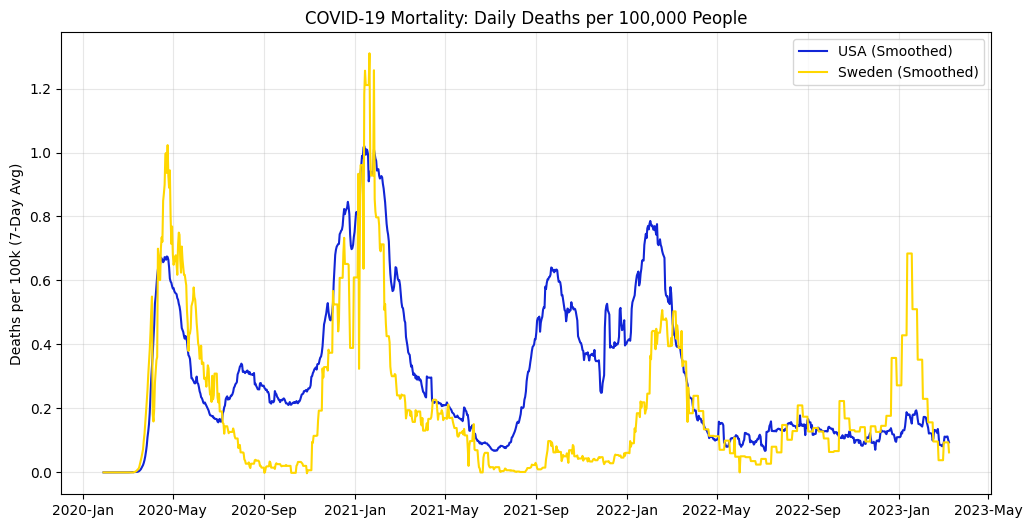

In [92]:
# 1. CLEAR the previous plot settings (This stops the "incompatible converter" error)
plt.close('all')

# 2. Re-force the dates to a standard format
usa_deaths_smooth.index = pd.to_datetime(usa_deaths_smooth.index)
swe_deaths_smooth.index = pd.to_datetime(swe_deaths_smooth.index)

# 3. Create the Plot
plt.figure(figsize=(12, 6))

# Use the .index explicitly
plt.plot(usa_deaths_smooth.index, usa_deaths_smooth.values, label='USA (Smoothed)', color='#1125D6')
plt.plot(swe_deaths_smooth.index, swe_deaths_smooth.values, label='Sweden (Smoothed)', color='gold')

# 4. Professional Formatting
plt.title("COVID-19 Mortality: Daily Deaths per 100,000 People")
plt.ylabel("Deaths per 100k (7-Day Avg)")
plt.legend()
plt.grid(alpha=0.3)

# The Formatter works once the index is cleaned
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))

plt.show()